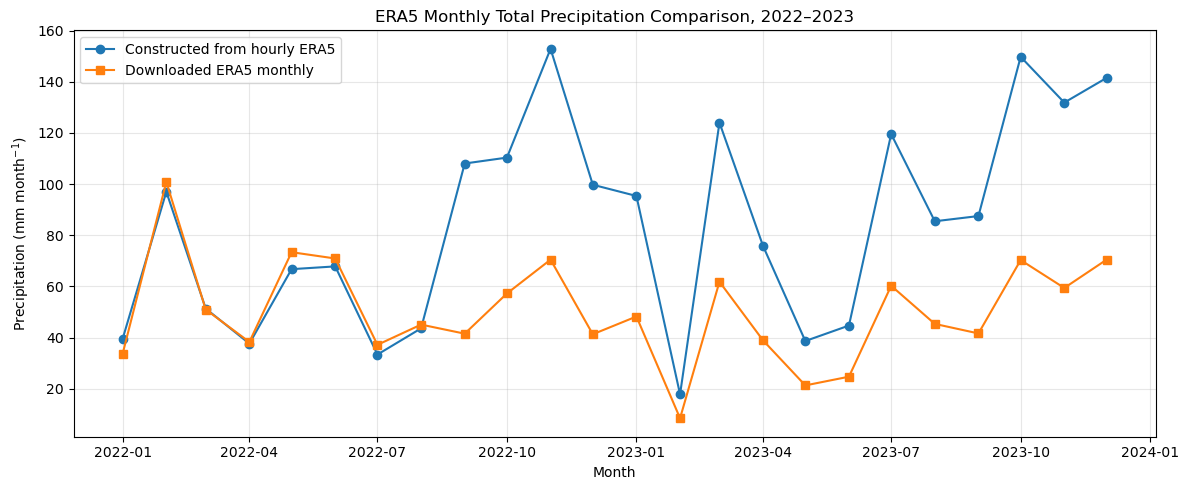

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# File paths
hourly_file = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\Hourly\tp_hourly_2223.nc"
monthly_file = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc"

# UK Box
lat_bounds = (61, 49)
lon_bounds = (-8, 2)

# Load data
ds_hourly = xr.open_dataset(hourly_file)
ds_monthly = xr.open_dataset(monthly_file)

time_h = "valid_time" if "valid_time" in ds_hourly.coords else "time"
time_m = "valid_time" if "valid_time" in ds_monthly.coords else "time"

tp_hourly = ds_hourly["tp"].sel({time_h: slice("2022-01-01", "2023-12-31")})
tp_monthly = ds_monthly["tp"].sel({time_m: slice("2022-01-01", "2023-12-31")})

# Apply UK box
def subset_box(da, lat_bounds, lon_bounds):
    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds

    if da.latitude[0] > da.latitude[-1]:
        da = da.sel(latitude=slice(lat_max, lat_min))
    else:
        da = da.sel(latitude=slice(lat_min, lat_max))

    da = da.sel(longitude=slice(lon_min, lon_max))
    return da

tp_hourly = subset_box(tp_hourly, lat_bounds, lon_bounds)
tp_monthly = subset_box(tp_monthly, lat_bounds, lon_bounds)

# Monthly totals from hourly

# Hourly tp is accumulated precip per timestep in metres
hourly_monthly_total = tp_hourly.resample({time_h: "MS"}).sum()

# Monthly tp is mean daily total in metres so multiply by days in month
days = tp_monthly[time_m].dt.days_in_month
downloaded_monthly_total = tp_monthly * days

# Spatial avg
def spatial_mean(da):
    weights = xr.DataArray(
        np.cos(np.deg2rad(da.latitude)),
        coords={"latitude": da.latitude},
        dims=["latitude"]
    )
    return da.weighted(weights).mean(("latitude", "longitude"))

hourly_monthly_mm = spatial_mean(hourly_monthly_total) * 1000
downloaded_monthly_mm = spatial_mean(downloaded_monthly_total) * 1000

# Make time coords consistent
if time_h != "time":
    hourly_monthly_mm = hourly_monthly_mm.rename({time_h: "time"})

if time_m != "time":
    downloaded_monthly_mm = downloaded_monthly_mm.rename({time_m: "time"})

# Load final arrays
hourly_monthly_mm = hourly_monthly_mm.compute()
downloaded_monthly_mm = downloaded_monthly_mm.compute()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_monthly_mm["time"],
    hourly_monthly_mm,
    marker="o",
    label="Constructed from hourly ERA5"
)

plt.plot(
    downloaded_monthly_mm["time"],
    downloaded_monthly_mm,
    marker="s",
    label="Downloaded ERA5 monthly"
)

plt.title("ERA5 Monthly Total Precipitation Comparison, 2022–2023")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm month$^{-1}$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 744. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 744. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
C:\Users\itsna\anaconda3\envs\climate\Lib\site-packages\xarray\core\dataset.py:277: UserWarning: The specified chunks separate the stored chunks along dimension "valid_time" starting at index 744. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(


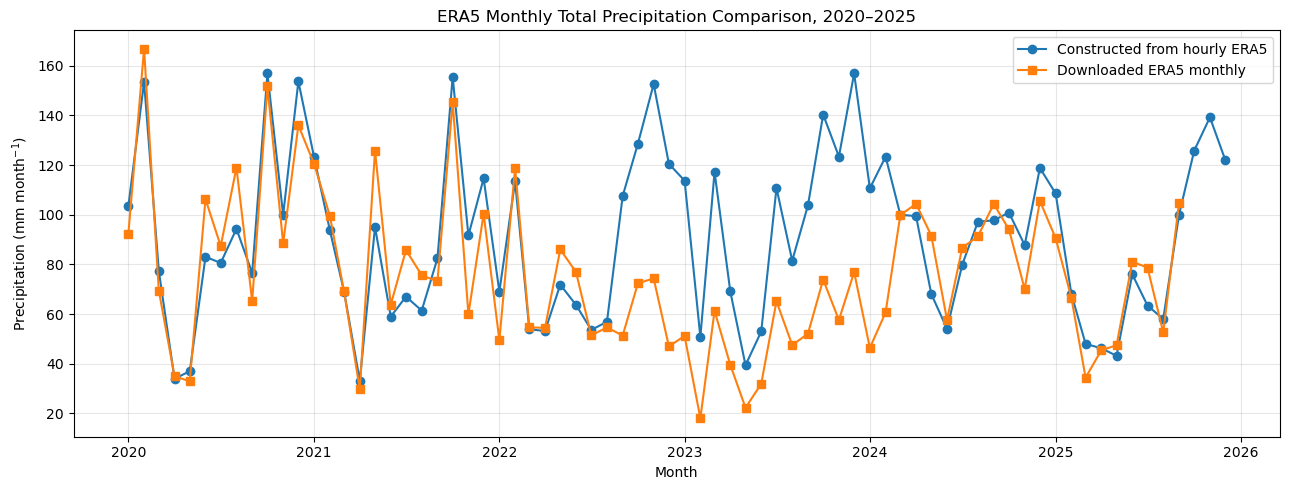

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

# File paths
hourly_path = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\Hourly"

hourly_files = [
    os.path.join(hourly_path, "tp_hourly_2021.nc"),
    os.path.join(hourly_path, "tp_hourly_2223.nc"),
    os.path.join(hourly_path, "tp_hourly_2425.nc"),
]

monthly_file = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\all_others.nc"

# UK Box
lat_bounds = (61, 49)
lon_bounds = (-8, 2)

def subset_box(ds, lat_bounds, lon_bounds):
    lat_min, lat_max = min(lat_bounds), max(lat_bounds)
    lon_min, lon_max = min(lon_bounds), max(lon_bounds)

    # Sort longitude to avoid non-monotonic combine errors
    ds = ds.sortby("longitude")

    # Latitude ascending or descending
    if ds.latitude[0] > ds.latitude[-1]:
        ds = ds.sel(latitude=slice(lat_max, lat_min))
    else:
        ds = ds.sel(latitude=slice(lat_min, lat_max))

    ds = ds.sel(longitude=slice(lon_min, lon_max))

    return ds

def preprocess_hourly(ds):
    return subset_box(ds, lat_bounds, lon_bounds)

# Load hourly data and crop each file before combining
ds_hourly = xr.open_mfdataset(
    hourly_files,
    combine="by_coords",
    preprocess=preprocess_hourly,
    chunks={"valid_time": 24 * 31}
)

ds_monthly = xr.open_dataset(monthly_file)

# Crop monthly data too
ds_monthly = subset_box(ds_monthly, lat_bounds, lon_bounds)

time_h = "valid_time" if "valid_time" in ds_hourly.coords else "time"
time_m = "valid_time" if "valid_time" in ds_monthly.coords else "time"

tp_hourly = ds_hourly["tp"].sel({time_h: slice("2020-01-01", "2025-12-31")})
tp_monthly = ds_monthly["tp"].sel({time_m: slice("2020-01-01", "2025-12-31")})

# Monthly totals from hourly
# Hourly tp is accumulated precip per timestep in metres
hourly_monthly_total = tp_hourly.resample({time_h: "MS"}).sum()

# Monthly tp is approximately mean daily total in metres,
# so multiply by days in month
days = tp_monthly[time_m].dt.days_in_month
downloaded_monthly_total = tp_monthly * days

# Spatial average
def spatial_mean(da):
    weights = xr.DataArray(
        np.cos(np.deg2rad(da.latitude)),
        coords={"latitude": da.latitude},
        dims=["latitude"]
    )
    return da.weighted(weights).mean(("latitude", "longitude"))

hourly_monthly_mm = spatial_mean(hourly_monthly_total) * 1000
downloaded_monthly_mm = spatial_mean(downloaded_monthly_total) * 1000

# Make time coords consistent just incase
if time_h != "time":
    hourly_monthly_mm = hourly_monthly_mm.rename({time_h: "time"})

if time_m != "time":
    downloaded_monthly_mm = downloaded_monthly_mm.rename({time_m: "time"})

# Load final arrays
hourly_monthly_mm = hourly_monthly_mm.compute()
downloaded_monthly_mm = downloaded_monthly_mm.compute()

# Plot
plt.figure(figsize=(13, 5))

plt.plot(
    hourly_monthly_mm["time"],
    hourly_monthly_mm,
    marker="o",
    label="Constructed from hourly ERA5"
)

plt.plot(
    downloaded_monthly_mm["time"],
    downloaded_monthly_mm,
    marker="s",
    label="Downloaded ERA5 monthly"
)

plt.title("ERA5 Monthly Total Precipitation Comparison, 2020–2025")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm month$^{-1}$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()